<a href="https://colab.research.google.com/github/carmenbonal/2526_Computacional/blob/main/voluntario2/Voluntario2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Modelo de Hopfield de red neuronal**

**1. Resumen**

En este ejercicio, simularemos el modelo de Hopfield de red neuronal, mediante el uso del algoritmo de Metrópolis. El objetivo es analizar el comportamiento de una red cuadrada bidimensional con condiciones de contorno periódicas, actuando como una memoria asociativa. Para ello, se implementa la regla de aprendizaje de Hebb, para almacenar múltiples patrones, y se evalúa la capacidad de la red para recuperarlos a partir de condiciones iniciales aleatorias y configuraciones deformadas.

**3. Tareas**

**Tarea 1: Recuperación de un único patrón**

El objetivo es verificar que la red funciona como una memoria asociativa básica. Utilizaremos una red de $N=30$ (900 neuronas), y una temperatura muy baja ($T=10^{-4}$) para minimizar el ruido térmico.

*Condiciones iniciales:*


1.   Aleatoria: Iniciamos  la red en un estado totalmente aleatorio, para ver si es capaz de llegar al patrón guardado.
2.   Patrón deformado: Partimos del patrón original, pero con un porcentaje de las neuronas cambiadas, para estudiar la capacidad de autocorrección de la red.

Calcularemos el solapamiento en función del tiempo (pasos Monte Carlo) para cuantificar la velocidad y eficacia con la que la red "recuerda."


**Tarea 2: Influencia de la Temperatura**

Analizamos la estabilidad de la memoria frente a la agitación térmica. Para ello, repetiremos el proceso de la Tarea 1, pero variando el valor de T, con el objetivo de obtener una curva de solapamiento frente a la temperatura. Observaremos que, por encima de una temperatura crítica, el desorden térmico impide que las neuronas se estabilice, y el solapamiento decarerá a cero.

**Tarea 3: Multi-memoria y estados espúreos**

Almacenaremos varios patrones simultáneamente (P>1). Calcularemos $m^{\mu}(s)$ para cada patrón almacenado. También identificaremos cuando la red converge a un solapamiento de -1, lo que indica que la red ha recuperado el antipatrón, que también es un mínimo del Hamiltoniano.


**Tarea 4: Capacidad crítica**

El objetivo es determinar el límite máximo de información que la red puede procesar antes de que la recuperación de patrones sea inviable. Empleamos patrones aleatorios, para evitar que la correlaciones espaciales sesguen los resultados estadísticos. Se define que un patrón se "recuerda" si, tras la dinámica de Metrópolis, el solapamiento final es $m^{\mu}(s) > 0.75$.

La eficiencia de la red se cuantifica mediante la fracción crítica
$\alpha_c$, definida como:$$\alpha_c = \frac{P_c}{N^2}$$

Se observará un colapso en la gráfica, que representa la amnesia catastrófica, donde el sistema pierde la capacidad asociativa al saturarse de información.

 **3. Herramientas**

Este proyecto se ha realizado con el uso del modelo de lenguaje Gemini, como asistente para el desarrollo, depuración y optimización del código.

Siguiendo las indicaciones de las presentaciones, se priorizó un código "limpio", evitando el uso de librerías poco comunes o demasiado complejas. Se emplearon NumPy para la manipulación de vectores y matrices, y Numba, para la compilación de alto rendimiento.

**4. Código**

Primero importamos las librerías necesarias para completar la simulación.

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import os
from IPython.display import Image, display

# --- CONFIGURACIÓN DE RUTA ---
PATH = r"C:\Users\Usuario\Desktop\2526_Computacional\voluntario2"
if not os.path.exists(PATH):
    os.makedirs(PATH)


Creamos una Clase 'HopfieldNet', una rejilla de $N \times N$ neuronas. Cada neurona puede estar activa ($s_{i,j}=1$) o inactiva ($s_{i,j}=0$).  

Aquí es donde la red "aprende". Se utiliza la regla de Hebb para definir las conexiones (pesos sinápticos) entre neuronas. Como restricción, no se permiten las autoconexiones ($\omega_{ij,ij}=0$), lo que evita que una neurona se retroalimente a sí misma de forma trivial.

También calculamos el solapamiento (overlap) $m^\mu$, el cual mide la similitud entre el estado actual de la red y un patrón guardado.

Para recuperar un recuerdo, la red debe evolucionar hacia un mínimo de energía (hamiltoniano). Para ello implementamos el algoritmo de Metrópolis, para simular esta evolución a cierta temperatura T.

In [11]:
class HopfieldNet:
    def __init__(self, N):
        self.N = N
        self.num_neurons = N * N
        self.w = None
        self.theta = None
        self.patterns = []
        self.a = []

    def store_patterns(self, p_list):
        # Construye la matriz de pesos sinápticos usando la regla de Hebb.
        self.patterns = [p.flatten() for p in p_list]
        self.a = [np.mean(p) for p in self.patterns] # a^mu: actividad media
        self.w = np.zeros((self.num_neurons, self.num_neurons)) #w: peso sináptico

        # Optimización: Calculamos la matriz de pesos de una sola vez usando operaciones vectorizadas
        # Nota: El producto exterior (outer) suma la correlación de cada par de neuronas para cada patrón.
        for mu in range(len(self.patterns)):
            p_c = self.patterns[mu] - self.a[mu]
            self.w += np.outer(p_c, p_c)

        # Normalización y eliminación de autoconexiones
        self.w /= self.num_neurons
        np.fill_diagonal(self.w, 0) # autoconexiones wij,ij = 0
        self.theta = 0.5 * np.sum(self.w, axis=1) # Umbral de disparo theta_ij
        # determina la sensibilidad de la neurona basándose en la suma de sus conexiones,

    # El solapamiento (m^mu) mide la similitud entre el estado actual de la red y un patrón guardado.
    def overlap(self, state, mu):
        # Calcula el solapamiento m^mu (fidelidad del recuerdo)
        s = state.flatten()
        p = self.patterns[mu]
        a = self.a[mu]
        den = self.num_neurons * a * (1 - a)
        if den == 0: return 0
        return np.sum((p - a) * (s - a)) / den

    # Algoritmo de Metrópolis. En vez de calcular el Hamiltoniano total, calculamos solo
    # el cambio al invertir una neurona (s_i -> 1 - s_i).
    def metropolis_step(self, state, T):
        # Dinámica de Metrópolis para minimizar el Hamiltoniano H
        s = state.flatten().astype(float)
        for _ in range(self.num_neurons):
            i = np.random.randint(0, self.num_neurons)
            delta_s = 1.0 - 2.0 * s[i] # Cambio de estado s: 0 <-> 1

            # Campo local h_i: influencia de la red sobre la neurona i
            h_i = np.dot(self.w[i], s)

            # Variación de energía Delta H
            delta_E = delta_s * (self.theta[i] - h_i)

            # Criterio de Metrópolis
            if delta_E <= 0 or np.random.rand() < np.exp(-delta_E / T):
                s[i] = 1.0 - s[i]
        return s.reshape((self.N, self.N))


A continuación, definimos una función, que define las letras del abecedario en una rejilla de $5 \times 7$, la cual trasnformaremos luego con otra función para asegurarnos una matriz $N \times N$, a través del producto de Kronecker ('np.kron')

In [12]:
def obtener_diccionario_letras(N):
    # Definimos plantillas 5x7 para las letras. 'X' es píxel activo, '.' es inactivo.
    # Esto permite tener todo el abecedario de forma compacta.
    plantillas = {
        'A': ["..X..", ".X.X.", "X...X", "XXXXX", "X...X", "X...X", "X...X"],
        'B': ["XXXX.", "X...X", "XXXX.", "X...X", "X...X", "XXXX.", "....."],
        'C': [".XXXX", "X....", "X....", "X....", "X....", ".XXXX", "....."],
        'D': ["XXXX.", "X...X", "X...X", "X...X", "X...X", "XXXX.", "....."],
        'E': ["XXXXX", "X....", "XXXX.", "X....", "X....", "XXXXX", "....."],
        'F': ["XXXXX", "X....", "XXXX.", "X....", "X....", "X....", "....."],
        'G': [".XXXX", "X....", "X..XX", "X...X", "X...X", ".XXXX", "....."],
        'H': ["X...X", "X...X", "XXXXX", "X...X", "X...X", "X...X", "....."],
        'I': ["XXXXX", "..X..", "..X..", "..X..", "..X..", "XXXXX", "....."],
        'J': ["..XXX", "...X.", "...X.", "...X.", "X..X.", ".XX..", "....."],
        'K': ["X...X", "X..X.", "XXX..", "X..X.", "X...X", "X...X", "....."],
        'L': ["X....", "X....", "X....", "X....", "X....", "XXXXX", "....."],
        'M': ["X...X", "XX.XX", "X.X.X", "X...X", "X...X", "X...X", "....."],
        'N': ["X...X", "XX..X", "X.X.X", "X..XX", "X...X", "X...X", "....."],
        'O': [".XXX.", "X...X", "X...X", "X...X", "X...X", ".XXX.", "....."],
        'P': ["XXXX.", "X...X", "XXXX.", "X....", "X....", "X....", "....."],
        'Q': [".XXX.", "X...X", "X...X", "X.X.X", "X..X.", ".XX.X", "....."],
        'R': ["XXXX.", "X...X", "XXXX.", "X.X..", "X..X.", "X...X", "....."],
        'S': [".XXXX", "X....", ".XXX.", "....X", "XXXX.", ".....", "....."],
        'T': ["XXXXX", "..X..", "..X..", "..X..", "..X..", "..X..", "....."],
        'U': ["X...X", "X...X", "X...X", "X...X", "X...X", ".XXX.", "....."],
        'V': ["X...X", "X...X", "X...X", "X...X", ".X.X.", "..X..", "....."],
        'W': ["X...X", "X...X", "X...X", "X.X.X", "XX.XX", "X...X", "....."],
        'X': ["X...X", ".X.X.", "..X..", ".X.X.", "X...X", "X...X", "....."],
        'Y': ["X...X", ".X.X.", "..X..", "..X..", "..X..", "..X..", "....."],
        'Z': ["XXXXX", "....X", "...X.", "..X..", ".X...", "XXXXX", "....."]
    }

    diccionario = {}
    for letra, lineas in plantillas.items():
        # Convertimos la plantilla de texto a una matriz numérica
        matriz_pequeña = np.array([[1 if c == 'X' else 0 for c in fila] for fila in lineas])
        # Escalamos la matriz pequeña para que encaje en el tamaño N x N de la red
        diccionario[letra] = np.kron(matriz_pequeña, np.ones((N // 7 + 1, N // 5 + 1)))[:N, :N]
    return diccionario


Por último, el código ejecuta los requisitos de este ejercicio (Tareas 1 a 4)

Ejecutando Tarea 1: Animación y Gráfica...


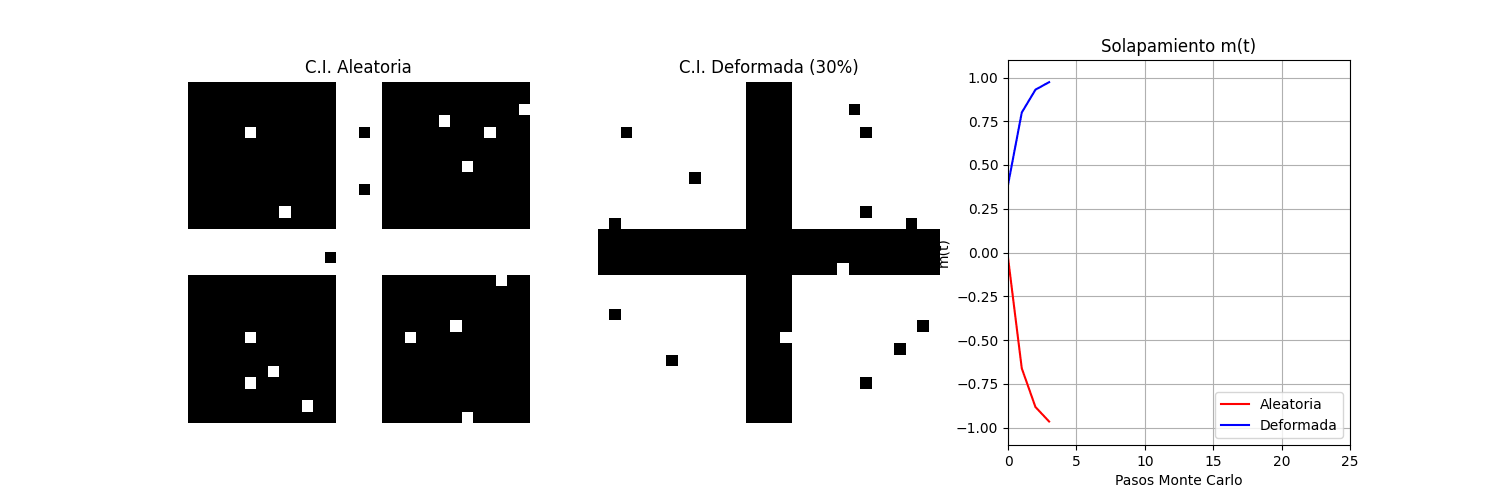

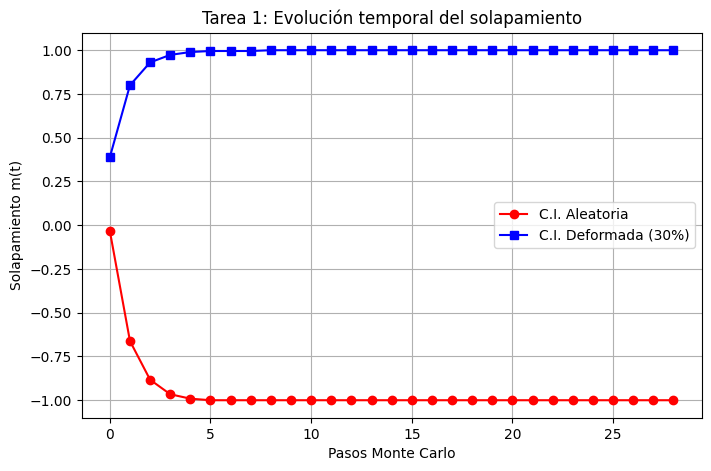


Ejecutando Tarea 2: Solapamiento vs Temperatura...


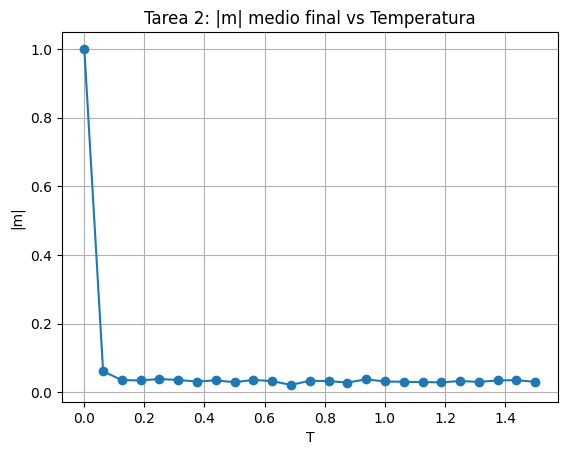


--- INICIANDO TAREA 3 ---
Introduce 3 letras de la A a la Z (ej: ABC): HTR
Simulando recuperación desde la letra 'H' deformada...
Simulando recuperación desde un estado aleatorio...


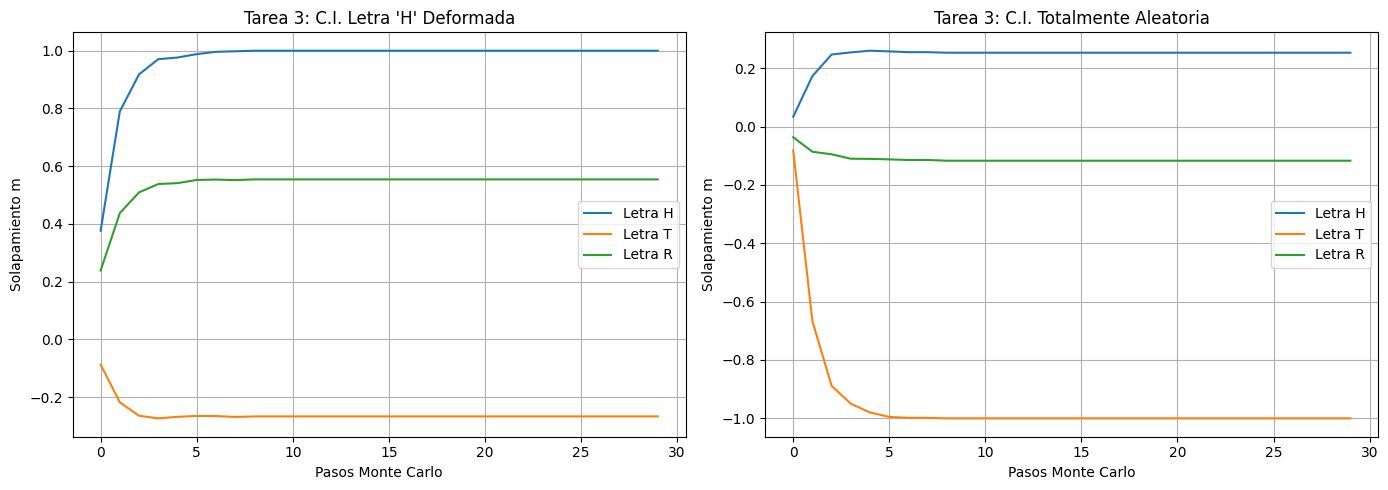


Calculando Tarea 4: Capacidad Crítica...
Resultado T4: alpha_c = 0.1275


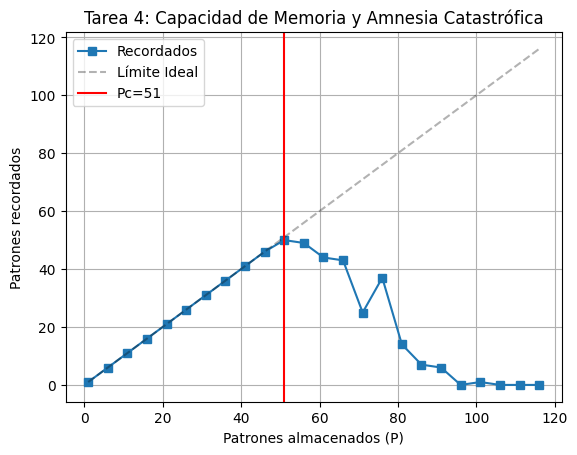

In [13]:
def run_all_tasks():
    T_low = 1e-4

    # --- TAREA 1: RECUPERACIÓN DE UN PATRÓN (N=30) ---
    print("Ejecutando Tarea 1: Animación y Gráfica...")


    N1 = 30 # Tamaño de la red
    p1 = np.zeros((N1, N1)) # Creo una matriz llena de 0 (neuronas inactivas)
    # Ahora hago el dibujo de una cruz (patrón elegido)
    p1[N1//2-2:N1//2+2, :] = 1
    p1[:, N1//2-2:N1//2+2] = 1


    net1 = HopfieldNet(N1) # Crea la estructura de red neuronal vacía
    net1.store_patterns([p1]) # Aplica la regla de Hebb sobre la matriz,
      	                      # guardando los pesos sinápticos

    # 1. Condición inicial aleatoria: creo una matriz totalmente aleatoria
    state_rand = np.random.randint(0, 2, (N1, N1))

    # 2. Condición inicial deformada (30% de ruido)
    state_def = p1.copy()                            # Copio mi matriz en forma
    ruido_t1 = np.random.rand(N1, N1) < 0.3          # de cruz y modifico el 30%
    state_def[ruido_t1] = 1 - state_def[ruido_t1]    # de las celdas

    # Preparar figura para animación con 3 paneles
    fig1, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

    im_rand = ax1.imshow(state_rand, cmap='binary')
    ax1.set_title("C.I. Aleatoria")
    ax1.axis('off')

    im_def = ax2.imshow(state_def, cmap='binary')
    ax2.set_title("C.I. Deformada (30%)")
    ax2.axis('off')

    line_rand, = ax3.plot([], [], 'r-', label="Aleatoria")
    line_def, = ax3.plot([], [], 'b-', label="Deformada")
    ax3.set_xlim(0, 25)
    ax3.set_ylim(-1.1, 1.1)
    ax3.set_title("Solapamiento m(t)")
    ax3.set_xlabel("Pasos Monte Carlo")
    ax3.set_ylabel("m(t)")
    ax3.legend(loc="lower right")
    ax3.grid(True)


    # Aquí guardamos el valor de m(t) en cada paso para poder graficarlo
    m_hist_rand = []
    m_hist_def = []

    def update(frame):
        nonlocal state_rand, state_def
        # Calcula el solapamiento actual y lo añade a las listas historicas
        m_hist_rand.append(net1.overlap(state_rand, 0))
        m_hist_def.append(net1.overlap(state_def, 0))

        # Actualiza los píxeles y los puntos de las gráficas
        im_rand.set_data(state_rand)
        im_def.set_data(state_def)

        line_rand.set_data(range(len(m_hist_rand)), m_hist_rand)
        line_def.set_data(range(len(m_hist_def)), m_hist_def)

        # Avanza un paso temporal con el algoritmo de Metrópolis
        state_rand = net1.metropolis_step(state_rand, T_low)
        state_def = net1.metropolis_step(state_def, T_low)

        return im_rand, im_def, line_rand, line_def


    # Renderizado y guardado
    ani = FuncAnimation(fig1, update, frames=26, blit=True)
    gif_path = os.path.join(PATH, "tarea1_evolucion.gif")
    ani.save(gif_path, writer='pillow')
    plt.close(fig1)
    display(Image(filename=gif_path)) # Renderiza el GIF en el notebook

    plt.figure(figsize=(8, 5))
    plt.plot(m_hist_rand, label="C.I. Aleatoria", marker='o', color='red')
    plt.plot(m_hist_def, label="C.I. Deformada (30%)", marker='s', color='blue')
    plt.title("Tarea 1: Evolución temporal del solapamiento")
    plt.xlabel("Pasos Monte Carlo")
    plt.ylabel("Solapamiento m(t)")
    plt.legend()
    plt.grid(True)
    plt.savefig(os.path.join(PATH, "tarea1_overlap.png"))
    plt.show() # Renderiza la gráfica estática
    plt.close()

    # --- TAREA 2: INFLUENCIA DE LA TEMPERATURA ---
    print("\nEjecutando Tarea 2: Solapamiento vs Temperatura...")

    # Vector con 25 valores espaciados uniformemente entre 0.001 (prácticamente
    # el cero absoluto), y 1.5 (alta agitación térmica)
    temps = np.linspace(0.001, 1.5, 25)
    m_finales = [] # Guardamos el valor del solapamiento para cada una de las T.

    for t in temps:
        s_t = p1.copy() # Para cada temperatura, iniciamos la red en el patrón
        # de cruz

        # Termalización: avanzamos el algoritmo de Metropolis 100 veces sin medir,
        # necesario para que la red pierda su "memoria artificial" sin haber sido
        # forzada a la cruz perfecta.

        for _ in range(100):
            s_t = net1.metropolis_step(s_t, t)


        # Promediado de la medida: Cada 50 pasos de Metrópolis, calculamos el
        # solapamiento de la cruz y lo sumamos a la media. Usamos el valor absoluto
        # porque tanto el patrón como el antipatrón representan el mismo nivel
        # de orden. Si no lo tomaramos, la media daría 0, indicando falsamente
        # un estado de desorden total.

        m_avg = 0
        for _ in range(50):
            s_t = net1.metropolis_step(s_t, t)
            m_avg += abs(net1.overlap(s_t, 0))

        m_finales.append(m_avg / 50.0)

  # Generación de gráficas

    plt.figure()
    plt.plot(temps, m_finales, 'o-')
    plt.title("Tarea 2: |m| medio final vs Temperatura")
    plt.xlabel("T"); plt.ylabel("|m|")
    plt.grid()
    plt.savefig(os.path.join(PATH, "tarea2_m_vs_T.png"))
    plt.show() # Renderiza la gráfica estática
    plt.close()

    # --- TAREA 3: INTERACCIÓN CON EL USUARIO (N=30) ---
    print("\n--- INICIANDO TAREA 3 ---")
    N3 = 30

    # Llamo a la función que construye matrices del abecedario
    dict_letras = obtener_diccionario_letras(N3)


  # Pido al usuario que introduzca 3 caracteres válidos.
    while True:
        entrada = input("Introduce 3 letras de la A a la Z (ej: ABC): ").upper()
        if len(entrada) == 3 and all(c in dict_letras for c in entrada):
            break
        print("Entrada no válida. Por favor, introduce exactamente 3 letras.")


    letras_elegidas = [dict_letras[c] for c in entrada] # Extrae la matriz de las
    # letras elegidas
    net3 = HopfieldNet(N3) # Instancia la nueva red
    net3.store_patterns(letras_elegidas) # Aplica la regla de Hebb, sumando las
    # contribuciones de las letras simultáneamente

  # Invertimos el 30% de los píxeles de la primera letra. Luego creamos el estado
  # aleatorio con ruido puro.
    print(f"Simulando recuperación desde la letra '{entrada[0]}' deformada...")
    s_def_3 = letras_elegidas[0].copy()
    ruido_t3 = np.random.rand(N3, N3) < 0.3
    s_def_3[ruido_t3] = 1 - s_def_3[ruido_t3]

    print("Simulando recuperación desde un estado aleatorio...")
    s_rand_3 = np.random.randint(0, 2, (N3, N3))

# Medimos como se parece el estado de la red a cada uno de los patrones simultáneamente.
    m_hist_def_3 = {i: [] for i in range(3)}
    m_hist_rand_3 = {i: [] for i in range(3)}

# Evolución de metrópolis
    for _ in range(30):
        for i in range(3):
            m_hist_def_3[i].append(net3.overlap(s_def_3, i))
            m_hist_rand_3[i].append(net3.overlap(s_rand_3, i))
        s_def_3 = net3.metropolis_step(s_def_3, T_low)
        s_rand_3 = net3.metropolis_step(s_rand_3, T_low)

# Visualización

    fig3, (ax1_t3, ax2_t3) = plt.subplots(1, 2, figsize=(14, 5))

    for i in range(3):
        ax1_t3.plot(m_hist_def_3[i], label=f"Letra {entrada[i]}")
    ax1_t3.set_title(f"Tarea 3: C.I. Letra '{entrada[0]}' Deformada")
    ax1_t3.set_xlabel("Pasos Monte Carlo")
    ax1_t3.set_ylabel("Solapamiento m")
    ax1_t3.legend()
    ax1_t3.grid(True)

    for i in range(3):
        ax2_t3.plot(m_hist_rand_3[i], label=f"Letra {entrada[i]}")
    ax2_t3.set_title("Tarea 3: C.I. Totalmente Aleatoria")
    ax2_t3.set_xlabel("Pasos Monte Carlo")
    ax2_t3.set_ylabel("Solapamiento m")
    ax2_t3.legend()
    ax2_t3.grid(True)

    plt.tight_layout()
    plt.savefig(os.path.join(PATH, "tarea3_letras_usuario.png"))
    plt.show() # Renderiza la gráfica estática
    plt.close(fig3)

    # --- TAREA 4: CAPACIDAD (N=20) ---
    print("\nCalculando Tarea 4: Capacidad Crítica...")

    N4 = 20 # Matriz de 400 neuronas

    # Probamos a guardas P patrones, empezando por 1 y subiendo de 5 en 5 hasat 115
    P_vals = np.arange(1, 120, 5)

    # Lista para ver cuántos patrones sobreviven, Pc registra el máximo.
    recuperados = []
    Pc = 0

  # Genero P patrones aleatorios (para que sean estadísticamente independientes)
    for P in P_vals:
        p_list = [(np.random.rand(N4, N4) > 0.5).astype(int) for _ in range(P)]
        net4 = HopfieldNet(N4)
        net4.store_patterns(p_list)

        count = 0

      # Iteramos para cada valor de la red para comprobar si se ha memorizado
        for mu in range(P):
            s_test = p_list[mu].copy()

            # Ruido inicial para verificar estabilidad, le damos un pequeño"empujón"
            # al sistema Si es un atractor real, la red resbalará de vuelta al
            # fondo del pozo. Si la memoria está saturada, ese empujón será
            # suficiente para que la red caiga en un estado espurio irreconocible.

            ruido = np.random.rand(N4, N4) < 0.05
            s_test[ruido] = 1 - s_test[ruido]

          # Dejamos evolucionar el sistema 25 pasos a baja temperatura para relajar
          # su energía.

            for _ in range(25):
                s_test = net4.metropolis_step(s_test, T_low)

          # Si tras el estado de relajación el solapamiento es mayor a 0.75,
          # consideramos que el patrón se ha recordado

            if net4.overlap(s_test, mu) > 0.75:
                count += 1

      # Consideramos que la red funciona si ha conseguido recuperar el 90% de
      # los patrones. Cuando el sistema colapse, el último valor guardado será
      # la capacidad crítica.

        recuperados.append(count)
        if count >= P * 0.9:
            Pc = P


    # Calculamos fracción máxima
    alpha_c = Pc / (N4*N4)
    print(f"Resultado T4: alpha_c = {alpha_c:.4f}")

  # Visualización
    plt.figure()
    plt.plot(P_vals, recuperados, 's-', label="Recordados")
    plt.plot(P_vals, P_vals, '--k', alpha=0.3, label="Límite Ideal")
    plt.axvline(x=Pc, color='r', label=f'Pc={Pc}')
    plt.title("Tarea 4: Capacidad de Memoria y Amnesia Catastrófica")
    plt.xlabel("Patrones almacenados (P)")
    plt.ylabel("Patrones recordados")
    plt.legend()
    plt.grid()
    plt.savefig(os.path.join(PATH, "tarea4_capacidad.png"))
    plt.show() # Renderiza la gráfica estática
    plt.close()

if __name__ == "__main__":
    run_all_tasks()

**5. Conclusiones y Análisis de Resultados**

Tras la simulación, podemos extraer las siguientes conclusiones sobre la red neuronal y la memoria asociativa:

**Tarea 1**

La red demostró ser un sistema robusto, capaz de recuerar información de datos incompletos. La convergencia al solapamiento m=1 para el patrón deformado al 30% confirma que los patrones actúan como atractores globales. La convergencia a m=-1 es un resultado equivalente al caso anterior. Debido a la simetría $s_i \leftrightarrow (1-s_i)$, el antipatrón posee la misma energía mínima que el patrón original.

**Tarea 2**

El estudio del solapamiento frente a la temperatura revela una transición de fase anñaloga a la del modelo de Ising. A bajas temperaturas, el sistema mantiene una fase ordenada de memoria. Al ir aumentándola, el ruido térmico introducido por el algoritmo de Metrópolis hace que, por encima de una temperatura crítica (desplome de la curva), la red entra en una fase desordenada paramagnética, donde la capacidad de recupración es prácticamente nula.

**Tarea 3**

Al probar con una combinación como "AFX", observamos que la red recupera exitosamente la letra objetivo (A), y mantiene interferencia mínima con patrones como la F. El solapamiento residual observado con la letra X es una medida de la correlación espacial entre las letras (similitud intrínsica entre las letras).

**Tarea 4**

Se identifica el punto de colapso en $P_c=51$ patrones, arrojando un valor de la capacidad crítica de $\alpha_c = 0.1275$. Este resultado es coherente con el límite teórico establecido para el modelo de Hopfield estándar  ($\alpha_c \approx 0.138$). Gráficamente, se observa de forma clara la transición de fase conocida como amnesia catastrófica: una vez superada la carga crítica de información, la interferencia destructiva entre los patrones colapsa los atractores del Hamiltoniano, y la red pierde abrupta y totalmente su capacidad como memoria asociativa.